In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from dataclasses import asdict
from pycontrails.models.gpat.pp_gpat import GPATPostProcessor
import os
import pyvista as pv
np.set_printoptions(threshold=np.inf, linewidth=500)


In [2]:
data_path = f"{os.getcwd()}/data/"

criteria = {
    "job_id": "GPAT_Feb_2026_test_2_ac",
}

pp_gpat = GPATPostProcessor(data_path, criteria)

Chunking the dataset
Set coords
Set index
Unstack the dataset
Normalize dimension order
Collapse broadcast altitude coordinate
Compute the result


In [3]:
fl_ds = pp_gpat.fl_ds_dict[pp_gpat.job_ids[0]]
fl_ds


<xarray.Dataset> Size: 54kB
Dimensions:               (seg_id: 239)
Coordinates:
    flight_id             (seg_id) int64 2kB ...
    waypoint              (seg_id) int64 2kB ...
  * seg_id                (seg_id) int64 2kB 1 2 3 4 5 6 ... 235 236 237 238 239
Data variables: (12/16)
    longitude             (seg_id) float64 2kB ...
    latitude              (seg_id) float64 2kB ...
    level                 (seg_id) float64 2kB ...
    altitude              (seg_id) float64 2kB ...
    time                  (seg_id) <U20 19kB ...
    true_airspeed         (seg_id) float64 2kB ...
    ...                    ...
    thrust                (seg_id) float64 2kB ...
    rocd                  (seg_id) float64 2kB ...
    fuel_flow_per_engine  (seg_id) float64 2kB ...
    thrust_setting        (seg_id) float64 2kB ...
    time_rel_s            (seg_id) int64 2kB ...
    time_idx              (seg_id) int64 2kB ...
Attributes:
    description:  Flight trajectory and emissions data for BOXM

In [4]:
pl_ds = pp_gpat.pl_ds_dict[pp_gpat.job_ids[0]]
pl_ds


<xarray.Dataset> Size: 8MB
Dimensions:          (seg_id: 239, time: 160, species_emi: 3)
Coordinates:
    flight_id        (seg_id) int64 2kB ...
    waypoint         (seg_id) int64 2kB ...
  * seg_id           (seg_id) int64 2kB 1 2 3 4 5 6 ... 234 235 236 237 238 239
  * time             (time) <U20 13kB '2022-01-20T13:00:00Z' ... '2022-01-20T...
    species_emi_num  (species_emi) int64 24B ...
  * species_emi      (species_emi) <U3 36B 'NO' 'CO' 'SO2'
    active_seg_flag  (seg_id, time) int64 306kB ...
    time_rel_s       (time) int64 1kB ...
    time_idx         (time) int64 1kB ...
Data variables: (12/15)
    age              (seg_id, time) <U21 3MB ...
    longitude        (seg_id, time) float64 306kB ...
    latitude         (seg_id, time) float64 306kB ...
    level            (seg_id, time) float64 306kB ...
    width            (seg_id, time) float64 306kB ...
    depth            (seg_id, time) float64 306kB ...
    ...               ...
    sigma_zz         (seg_id, time) float64 306kB ...
    longitude_m      (seg_id, time) float64 306kB ...
    latitude_m       (seg_id, time) float64 306kB ...
    altitude         (seg_id, time) float64 306kB ...
    emi_pl_mass      (seg_id, species_emi) float64 6kB ...
    age_s            (seg_id, time) int64 306kB ...
Attributes: (12/14)
    nseg:              239
    ts_fl:             60.0
    ts_pl:             60.0
    ts_sim:            20.0
    ts_out:            60.0
    species_emi:       ['NO', 'CO', 'SO2']
    ...                ...
    species_pl_num:    [  8   4   6   5   7  14  13  15 198 217  12 144  11  ...
    n_slices:          3
    f_max:             0.99
    output_pl_slices:  1
    n_points:          32
    description:       Emission species mass in plume segments

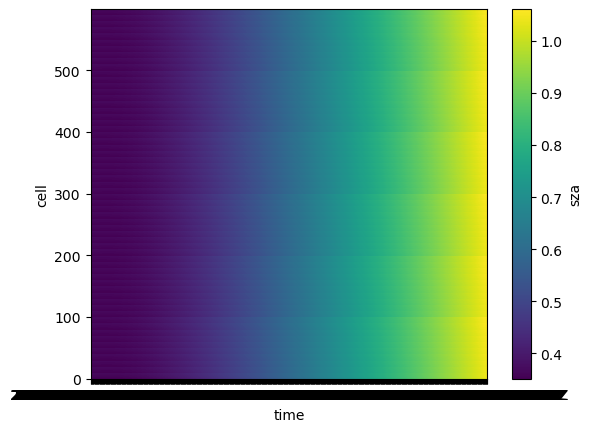

In [21]:
boxm_ds = pp_gpat.boxm_ds_dict[pp_gpat.job_ids[0]]
boxm_ds["sza"].plot()


In [6]:
pl_out = pp_gpat.pl_out_dict[pp_gpat.job_ids[0]]
pl_out

<xarray.Dataset> Size: 71MB
Dimensions:         (seg_id: 239, time: 241, species_pl: 17, slice_id: 3,
                     pt_id: 32, coord: 3, corner_id: 4)
Coordinates:
    flight_id       (seg_id) int64 2kB ...
    waypoint        (seg_id) int64 2kB ...
  * seg_id          (seg_id) int64 2kB 1 2 3 4 5 6 7 ... 234 235 236 237 238 239
  * time            (time) <U20 19kB '2022-01-20T12:00:00Z' ... '2022-01-20T1...
  * species_pl      (species_pl) <U8 544B 'NO' 'NO2' 'O3' ... 'HCHO' 'SO2' 'SA'
  * slice_id        (slice_id) int64 24B 1 2 3
  * pt_id           (pt_id) int64 256B 1 2 3 4 5 6 7 8 ... 26 27 28 29 30 31 32
  * coord           (coord) <U5 60B 'lon_m' 'lat_m' 'alt_m'
  * corner_id       (corner_id) <U2 32B 'BL' 'TL' 'TR' 'BR'
    species_pl_num  (species_pl) int64 136B ...
    time_rel_s      (time) int64 2kB ...
    time_idx        (time) int64 2kB ...
Data variables:
    y_half          (seg_id, slice_id, time) float64 1MB ...
    z_half          (seg_id, slice_id, time) float64 1MB ...
    m_frac          (slice_id) float64 24B ...
    w_slice         (slice_id) float64 24B ...
    ellipses_m      (seg_id, pt_id, coord, time) float64 44MB ...
    slice_polys_m   (seg_id, slice_id, corner_id, coord, time) float64 17MB ...
    pl_mass         (seg_id, species_pl, time) float64 8MB ...
Attributes:
    description:  Plume segment output for BOXM

In [7]:
boxm_out = pp_gpat.boxm_out_dict[pp_gpat.job_ids[0]]
boxm_out["Y_bg_c"].isel(level_c=3).sel(species_out="NO").values


array([[[1.72000594e+03, 6.80130144e-07, 4.61745450e-01, 1.66011034e-04, 3.60678651e-02, 2.17647847e-03, 1.87622885e-01, 4.39823474e-02, 8.34634887e-07, 1.54256663e-02],
        [3.00572754e-05, 7.99022762e-05, 2.40643401e-03, 1.71440860e-05, 6.84250243e-09, 2.63904910e-02, 2.30437709e-05, 9.32970505e-06, 9.70434081e-02, 2.58660468e-05],
        [9.55565361e-06, 1.32142246e-02, 1.02325401e-04, 6.93571370e-07, 1.30675794e-02, 6.05342668e-06, 2.36546691e-03, 2.19673143e-04, 1.41435135e-05, 1.33293012e-02],
        [6.67743295e-04, 2.82456928e-02, 4.66293183e-04, 2.94787346e+01, 8.33883857e-05, 2.03834066e-02, 2.90810658e-02, 1.04336551e-05, 7.29155236e+01, 2.61149777e-01],
        [1.78605588e-02, 2.18660316e-02, 5.71238436e-03, 8.17774747e-02, 2.69148639e-06, 5.37859218e-05, 2.29138978e-01, 2.14585012e-07, 9.06678482e+02, 1.83505935e-03],
        [2.43826854e-01, 2.36728574e+00, 5.96204875e-01, 1.43223123e-03, 1.23123604e-03, 1.66623012e+00, 5.05027230e+00, 1.93969277e-02, 2.15334177e-0

In [8]:
# xarray requires monotonic indexes for method="nearest" on indexed coords
for coord in ["longitude_c", "latitude_c", "level_c"]:
    if coord in boxm_out.coords:
        boxm_out = boxm_out.sortby(coord)

# Select string labels exactly, then use nearest only on numeric coords
boxm_out_no = boxm_out.sel(species_out="NO")
boxm_out_no["Y_bg_c"].sel(level_c=201.1, method="nearest").isel(time=183).values

array([[2.28094674e+00, 9.07588673e-03, 1.09411043e+02, 6.49014875e+00, 1.70766985e-01, 7.82426279e-03, 6.17762977e-02, 9.41910142e-03, 2.61879239e+01, 5.70097670e-03],
       [5.55394965e-02, 5.23611060e+00, 1.65951779e-03, 1.08434853e+00, 4.04623061e-02, 2.89905766e-03, 5.88834556e+00, 1.82952452e+02, 5.94649631e-01, 1.74518517e-02],
       [1.97885892e+00, 2.18270439e+00, 9.29951188e-02, 8.67386197e+00, 9.10924812e-02, 1.17801554e-02, 7.28411290e+01, 4.85778751e-03, 4.52156444e-02, 2.38487083e-04],
       [2.16359698e-02, 6.49269829e-03, 2.17824554e+01, 4.08012651e-03, 1.30456407e-03, 1.22901954e+00, 3.60632701e-05, 5.20912169e-03, 3.07233706e-03, 3.37145703e-02],
       [1.61369683e-02, 1.21011511e+00, 9.11572177e-02, 7.32206802e-04, 8.54345364e-02, 2.75896418e-02, 3.22247168e+00, 1.53170126e+00, 8.61440898e-02, 2.89912635e-03],
       [7.59351802e-02, 1.02061640e-02, 2.35606971e-01, 8.49919106e-04, 4.88631995e-02, 6.34277506e-03, 3.93138669e+01, 1.00409295e-01, 1.12618756e-02, 9.1

In [9]:
patch_table = pp_gpat.patch_table_dict[pp_gpat.job_ids[0]]
patch_table

<xarray.Dataset> Size: 15MB
Dimensions:          (row: 73684, species_out: 16)
Coordinates:
  * row              (row) int64 589kB 1 2 3 4 5 ... 73681 73682 73683 73684
  * species_out      (species_out) <U6 384B 'O3' 'NO2' 'NO' ... 'PAN' 'SO2'
    species_out_num  (species_out) int64 128B ...
    time             (row) float64 589kB ...
    time_rel_s       (row) int64 589kB ...
    time_idx         (row) int64 589kB ...
    row_cell_c       (row) int64 589kB ...
    row_cell_f       (row) int64 589kB ...
    latitude_f       (row) float64 589kB ...
    longitude_f      (row) float64 589kB ...
    altitude_f       (row) float64 589kB ...
    level_f          (row) float64 589kB ...
Data variables:
    Y_del_f          (row, species_out) float64 9MB ...
Attributes:
    description:  Fine grid plume patch output for BOXM

In [10]:
boxm_out.longitude_c.values

array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95])

In [11]:
patch_table["Y_del_f"].sel(row=slice(0, 100), species_out="NO").values

array([3.11313357e-10, 1.80240616e-10, 1.65021281e-08, 9.61956121e-09, 1.38270683e-09, 7.51167498e-10, 3.62034605e-08, 2.09707097e-08, 6.10581114e-11, 3.30316699e-09, 2.16735427e-10, 7.10035675e-09, 3.15519196e-08, 1.83232749e-08, 6.23905623e-09, 1.51863459e-08, 8.79524534e-09, 2.97655256e-09, 4.05793611e-10, 1.97719707e-10, 3.87335339e-11, 4.25914024e-10, 2.49290120e-10, 1.77834312e-08, 1.16029939e-08, 3.25543271e-08, 3.57569048e-08, 8.64071782e-11, 3.61075036e-09, 6.55899110e-09,
       2.89230567e-08, 5.21284293e-08, 5.78953666e-09, 1.39645531e-08, 4.40354376e-08, 7.52852513e-12, 1.23453972e-09, 2.76382390e-09, 1.13763347e-10, 1.26122864e-08, 2.44552702e-12, 2.71435485e-10, 5.59928524e-10, 3.33150543e-10, 1.78924848e-08, 1.19257887e-08, 3.20989239e-08, 2.93267204e-08, 1.19431834e-10, 3.81144146e-09, 6.82346095e-09, 1.17583054e-10, 5.57385878e-11, 9.50950509e-12, 2.86592932e-08, 6.05757944e-08, 9.35675459e-12, 1.34318987e-08, 1.71028983e-09, 7.52621830e-08,
       5.96412871e-09, 4.8

In [12]:
patch_table["row_cell_c"].sel(row=slice(0, 100)).values

array([401, 401, 402, 402, 411, 411, 412, 412, 501, 502, 511, 512, 412, 412, 512, 412, 412, 512, 412, 412, 512, 401, 401, 402, 402, 412, 412, 501, 502, 512, 412, 412, 512, 412, 412, 412, 412, 512, 412, 412, 412, 412, 401, 401, 402, 402, 412, 412, 501, 502, 512, 402, 402, 502, 412, 412, 412, 412, 412, 412, 512, 412, 412, 412, 412, 412, 412, 512, 512, 412, 412, 401, 401, 402, 402, 402, 402, 412, 412, 501, 502, 502, 512, 412, 412, 412, 412, 412, 412, 512, 412, 412, 412, 412, 412, 412, 512, 512,
       412, 412])

In [13]:
patch_table["row_cell_f"].sel(row=slice(0, 100)).values

array([16, 32,  4, 20, 13, 29,  1, 17, 32, 20, 29, 17,  5, 21, 21,  6, 22, 22,  2, 18, 18, 16, 32,  4, 20,  1, 17, 32, 20, 17,  5, 21, 21,  6, 22,  2, 18, 22, 10, 26, 11, 27, 16, 32,  4, 20,  1, 17, 32, 20, 17,  8, 24, 24,  5, 21,  2,  6, 18, 22, 21, 10, 26, 11, 27,  9, 25, 22, 25,  7, 23, 16, 32,  4,  8, 20, 24,  1, 17, 32, 20, 24, 17,  5, 21,  6, 22, 10, 26, 21,  9, 25, 11, 27,  7, 23, 22, 25, 15, 31])

In [14]:
import numpy as np
import pandas as pd
import json
import ast
import re

job_id = pp_gpat.job_ids[0]
pt = pp_gpat.patch_table_dict[job_id]
boxm_ds = pp_gpat.boxm_ds_dict[job_id]
sim_raw = pp_gpat.params_dict[job_id]["sim_params"]

def _extract_sim_value(sim_obj, key):
    if isinstance(sim_obj, dict):
        return float(sim_obj[key])
    if isinstance(sim_obj, str):
        # 1) JSON-like
        try:
            obj = json.loads(sim_obj)
            if isinstance(obj, dict) and key in obj:
                return float(obj[key])
        except Exception:
            pass
        # 2) Python literal-like
        try:
            obj = ast.literal_eval(sim_obj)
            if isinstance(obj, dict) and key in obj:
                return float(obj[key])
        except Exception:
            pass
        # 3) Dataclass repr-like: ... key=0.001 ...
        m = re.search(rf"{key}\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", sim_obj)
        if m:
            return float(m.group(1))
    raise ValueError(f"Could not extract '{key}' from sim_params")

hres_sim_c = _extract_sim_value(sim_raw, "hres_sim_c")
hres_sim_f = _extract_sim_value(sim_raw, "hres_sim_f")
vres_sim_c = _extract_sim_value(sim_raw, "vres_sim_c")
vres_sim_f = _extract_sim_value(sim_raw, "vres_sim_f")

print("hres_sim_c:", hres_sim_c, "hres_sim_f:", hres_sim_f)
print("vres_sim_c:", vres_sim_c, "vres_sim_f:", vres_sim_f)

# Match Fortran NINT behavior
nx_f = max(1, int(np.rint(hres_sim_c / hres_sim_f)))
ny_f = nx_f
nz_f = max(1, int(np.rint(vres_sim_c / vres_sim_f)))

hres_f_deg = hres_sim_c / nx_f
dz_f = vres_sim_c / nz_f

row_cell_c = pt["row_cell_c"].values.astype(int)
row_cell_f = pt["row_cell_f"].values.astype(int)

# 1) Basic index-range checks
print("row_cell_c range:", row_cell_c.min(), row_cell_c.max(), "ncell:", boxm_ds.sizes["cell"])
print("row_cell_f range:", row_cell_f.min(), row_cell_f.max(), "local max:", nx_f * ny_f * nz_f)

# 2) Decode local fine indices (same as Fortran)
iz_f = (row_cell_f - 1) // (nx_f * ny_f) + 1
rem_f = (row_cell_f - 1) % (nx_f * ny_f)
iy_f = rem_f // nx_f + 1
ix_f = rem_f % nx_f + 1

# 3) Pull coarse-cell centers
lat_c = boxm_ds["latitude_c"].values[row_cell_c - 1]
lon_c = boxm_ds["longitude_c"].values[row_cell_c - 1]
alt_c = boxm_ds["altitude_c"].values[row_cell_c - 1]

# 4) Recompute expected fine-cell centers
lat_exp = lat_c - 0.5 * hres_sim_c + (iy_f - 0.5) * hres_f_deg
lon_exp = lon_c - 0.5 * hres_sim_c + (ix_f - 0.5) * hres_f_deg
alt_exp = alt_c - 0.5 * vres_sim_c + (iz_f - 0.5) * dz_f

# 5) Compare to stored patch coords
lat_err = np.abs(lat_exp - pt["latitude_f"].values)
lon_err = np.abs(lon_exp - pt["longitude_f"].values)
alt_err = np.abs(alt_exp - pt["altitude_f"].values)

print("max |lat error|:", np.nanmax(lat_err))
print("max |lon error|:", np.nanmax(lon_err))
print("max |alt error|:", np.nanmax(alt_err))

# Optional: inspect worst rows
worst = np.argsort(lat_err + lon_err + alt_err)[-5:]
print(pd.DataFrame({
    "row": worst,
    "row_cell_c": row_cell_c[worst],
    "row_cell_f": row_cell_f[worst],
    "lat_err": lat_err[worst],
    "lon_err": lon_err[worst],
    "alt_err": alt_err[worst],
}))

hres_sim_c: 0.1 hres_sim_f: 0.025
vres_sim_c: 500.0 vres_sim_f: 250.0
row_cell_c range: 129 512 ncell: 600
row_cell_f range: 1 32 local max: 32
max |lat error|: 0.0
max |lon error|: 0.0
max |alt error|: 0.0
     row  row_cell_c  row_cell_f  lat_err  lon_err  alt_err
0     16         412          22      0.0      0.0      0.0
1  73681         250          23      0.0      0.0      0.0
2  73682         250          26      0.0      0.0      0.0
3  73683         250          29      0.0      0.0      0.0
4      0         401          16      0.0      0.0      0.0


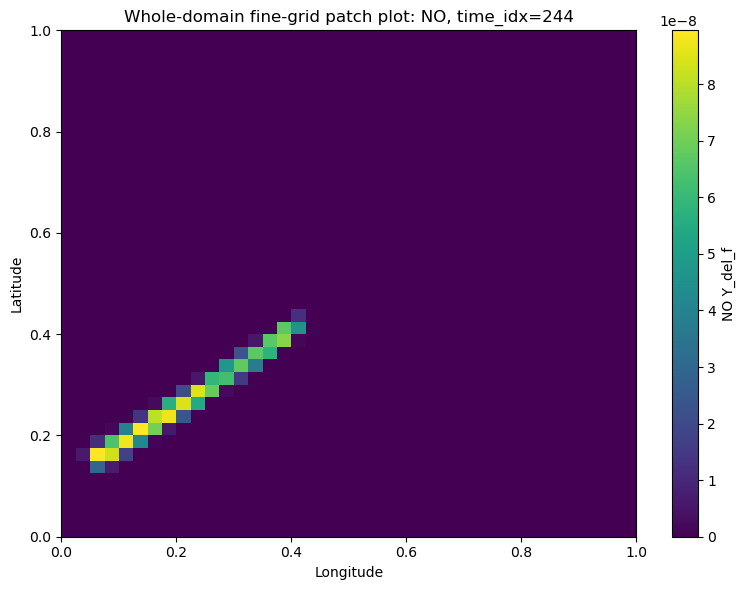

<xarray.DataArray 'Y_del_f_NO' (latitude_f: 40, longitude_f: 40)> Size: 13kB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 2.91460500e-08, 6.55349078e-09, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00

In [15]:
import matplotlib.pyplot as plt

species = "NO"
time_idx_plot = 184 + 3*20

# Whole-domain fine-grid centers from simulation bounds
lat0 = _extract_sim_value(sim_raw, "lat_bounds") if False else None
lon0 = _extract_sim_value(sim_raw, "lon_bounds") if False else None

# lat/lon bounds are tuples in sim_raw, so parse separately
sim_text = sim_raw if isinstance(sim_raw, str) else str(sim_raw)
lat_match = re.search(r"lat_bounds\s*=\s*\(([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?),\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\)", sim_text)
lon_match = re.search(r"lon_bounds\s*=\s*\(([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?),\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\)", sim_text)

if lat_match is None or lon_match is None:
    raise ValueError("Could not extract lat/lon bounds from sim_params")

lat_min = float(lat_match.group(1))
lat_max = float(lat_match.group(2))
lon_min = float(lon_match.group(1))
lon_max = float(lon_match.group(2))

lat_centers = np.arange(lat_min + 0.5 * hres_sim_f, lat_max, hres_sim_f)
lon_centers = np.arange(lon_min + 0.5 * hres_sim_f, lon_max, hres_sim_f)

vals = pt["Y_del_f"].sel(species_out=species).values
time_rows = pt["time_idx"].values.astype(int)

mask = np.isfinite(vals) & (vals != 0.0) & (time_rows == time_idx_plot)

# Use validated local fine indices + coarse cell centers to place values exactly
lat_plot = lat_exp[mask]
lon_plot = lon_exp[mask]
val_plot = vals[mask]

j = np.floor((lat_plot - lat_min) / hres_sim_f).astype(int)
i = np.floor((lon_plot - lon_min) / hres_sim_f).astype(int)

inside = (j >= 0) & (j < lat_centers.size) & (i >= 0) & (i < lon_centers.size)
j = j[inside]
i = i[inside]
v = val_plot[inside]

grid = np.zeros((lat_centers.size, lon_centers.size), dtype=float)
np.add.at(grid, (j, i), v)

da_plot = xr.DataArray(
    grid,
    coords={"latitude_f": lat_centers, "longitude_f": lon_centers},
    dims=("latitude_f", "longitude_f"),
    name=f"Y_del_f_{species}",
)

plt.figure(figsize=(8, 6))
mesh = plt.pcolormesh(
    da_plot["longitude_f"].values,
    da_plot["latitude_f"].values,
    da_plot.values,
    shading="auto",
    cmap="viridis",
)
plt.colorbar(mesh, label=f"{species} Y_del_f")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Whole-domain fine-grid patch plot: {species}, time_idx={time_idx_plot}")
plt.tight_layout()
plt.show()

da_plot

In [16]:
nonzero = np.argwhere(grid != 0.0)
print('grid shape:', grid.shape)
print('lat range:', float(lat_centers.min()), float(lat_centers.max()), 'step:', float(hres_sim_f))
print('lon range:', float(lon_centers.min()), float(lon_centers.max()), 'step:', float(hres_sim_f))
print('nonzero cell count:', nonzero.shape[0])
print('masked patch rows:', int(mask.sum()))
print('inside rows:', int(inside.sum()))
print('value min/max:', float(v.min()) if v.size else None, float(v.max()) if v.size else None)
print('occupied grid indices and centers:')
for row_idx, col_idx in nonzero[:20]:
    print(
        int(row_idx),
        int(col_idx),
        float(lat_centers[row_idx]),
        float(lon_centers[col_idx]),
        float(grid[row_idx, col_idx]),
    )
print('unique lat_plot:', np.unique(np.round(lat_plot, 6))[:20])
print('unique lon_plot:', np.unique(np.round(lon_plot, 6))[:20])

grid shape: (40, 40)
lat range: 0.0125 0.9875000000000002 step: 0.025
lon range: 0.0125 0.9875000000000002 step: 0.025
nonzero cell count: 54
masked patch rows: 143
inside rows: 143
value min/max: 8.426623342954561e-12 8.037260917036453e-08
occupied grid indices and centers:
5 2 0.13750000000000004 0.06250000000000001 2.914604997331303e-08
5 3 0.13750000000000004 0.08750000000000001 6.5534907776853845e-09
6 1 0.16250000000000003 0.037500000000000006 6.074586230991789e-09
6 2 0.16250000000000003 0.06250000000000001 8.952947059054842e-08
6 3 0.16250000000000003 0.08750000000000001 8.296495771129411e-08
6 4 0.16250000000000003 0.11250000000000002 1.681189487891296e-08
6 5 0.16250000000000003 0.13750000000000004 7.146037618482786e-11
7 2 0.18750000000000006 0.06250000000000001 1.1781011004507932e-08
7 3 0.18750000000000006 0.08750000000000001 6.432033008629278e-08
7 4 0.18750000000000006 0.11250000000000002 8.771088192577705e-08
7 5 0.18750000000000006 0.13750000000000004 4.19106902176675e